# Example: Analysis of a Synthetic Covered Call Position on AMD
In this example, we analyze a synthetic covered call position on Advanced Micro Devices, Inc. (AMD) using historical options data. A synthetic covered call replicates a traditional covered call by using a deep in-the-money call option instead of purchasing shares, combined with a short call at a higher strike price.

> __Learning Objectives:__
> 
> By the end of this example, you should be able to:
> * __Construct profit diagrams for synthetic covered call positions:__ Build profit and loss profiles for synthetic covered calls by combining a long deep in-the-money call with a short out-of-the-money call, and compute the breakeven point, maximum profit, and maximum loss scenarios.
> * __Calculate probabilities for synthetic covered call outcomes:__ Use cumulative distribution functions of projected share price distributions to determine the likelihood of maximum profit, maximum loss, and breakeven scenarios at expiration.
> * __Compare synthetic positions to traditional covered calls:__ Evaluate the cost advantage of using a deep in-the-money call option as a stock replacement and verify proper strike selection relative to the long call's breakeven point.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [VLQuantitativeFinancePackage.jl documentation](https://github.com/varnerlab/VLQuantitativeFinancePackage.jl).

### Data
To start, load the options data using [the `MyOptionsChainDataSet(...)` function](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/data/#VLQuantitativeFinancePackage.MyOptionsChainDataSet) and store the metadata in the `metadata::Dict{String,Any}` variable and the options chain data in the `optionschain::DataFrame` variable.

In [2]:
metadata, optionschain, ticker = let
    
    # initialize -
    ticker = "amd";
    options_dataset = MyOptionsChainDataSet(ticker = ticker);
    metadata = options_dataset.metadata;
    optionschain = options_dataset.data;

    (metadata, optionschain, ticker) # return
end;

What's in the `metadata::Dict{String,Any}` dictionary? 

In [3]:
let

    # initialize -
    df = DataFrame();
    fields = metadata |> keys |> collect |> sort;

    for i ∈ eachindex(fields)
        field = fields[i];
        row_df = (
            field = field |> String,
            value = metadata[field] |> string,
        );
        push!(df, row_df);
    end

    # make a table -
    pretty_table(
         df;
         fit_table_in_display_horizontally = false,
         backend = :text,
         table_format = TextTableFormat(borders = text_table_borders__compact)
    );

end

 ---------------------------- --------------
                       field          value 
                      String         String 
 ---------------------------- --------------
                         DTE             58
                      atm_IV         0.5903
             expiration_date     2025-12-19
       historical_volatility         0.7971
                   is_weekly          false
               purchase_date     2025-10-22
                      source   barchart.com
  underlying_share_price_ask         225.91
  underlying_share_price_bid         225.74
  underlying_share_price_mid         225.78
 ---------------------------- --------------


What about the `optionschain::DataFrame` variable?

In [4]:
optionschain

Row,Strike,Moneyness,Bid,Mid,Ask,Last,Volume,Open Int,IV,Delta,Type
,Float64,Float64,Float64,Float64,Float64,Float64,String7,String7,Float64,Float64,String7
1,25.0,0.8907,203.1,204.0,204.9,209.72,0,419,2.1122,0.9989,Call
2,30.0,0.8688,198.2,199.05,199.9,206.3,0,163,1.9784,0.9985,Call
3,35.0,0.847,193.2,193.98,194.75,199.75,0,17,0.0,0.0,Call
4,40.0,0.8251,188.3,189.1,189.9,176.24,0,18,1.6654,0.9985,Call
5,45.0,0.8033,183.25,184.13,185.0,174.11,0,318,1.5375,0.9985,Call
6,50.0,0.7814,178.4,179.1,179.8,167.46,0,691,1.2356,0.9996,Call
7,55.0,0.7596,173.35,174.13,174.9,177.43,0,176,1.0885,0.9998,Call
8,60.0,0.7377,168.5,169.3,170.1,162.15,0,332,1.3802,0.9967,Call
9,65.0,0.7158,163.45,164.33,165.2,175.38,0,180,1.2927,0.9967,Call


### Constants
Let's set a value for the step size `Δt::Float64`, i.e., `1 day` in units of years (assuming a `365-day` year), and the risk-free rate at the time we gathered the data for the option contracts; we approximate this value using the [yield on the 10-year Treasury Note](https://ycharts.com/indicators/10_year_treasury_rate). We also set a value for the underlying share price `Sₒ::Float64`, the number of levels in the binomial tree model `h::Int64`, the strike price `K::Float64`, and the direction parameter `θ::Int64`.

In [5]:
Sₒ = metadata["underlying_share_price_mid"] |> x-> parse(Float64, x); # mid underlying price on purchase date, 10-22-2025

Other constants:

In [6]:
DTE = metadata["DTE"] |> x-> parse(Float64, x); # days to expiration
Δt = (1/365); # Time step 1-trading day
risk_free_rate = 0.0431; # yield 10-year treasury note on 13-Jun-2024
number_of_points_per_day = 10; # number of levels per day
h = DTE*number_of_points_per_day; # levels in the binomial lattice
w = 0.3; # width parameter

___

## Task 1: Select a random call option from the dataset
In this task, we'll select call option contracts such that $S_{\circ}<K\leq\left(1+w\right)\cdot{S}_{\circ}$ where $w>0$. We will build a synthetic covered call by selling this call contract and buying a deep in-the-money call to replace the shares. Let's begin by filtering the contracts in the `optionschain::DataFrame` to include only `call` contracts that obey the strike price constraint.

Save the filtered selection of `call` contracts in the `call_contracts::DataFrame` variable:

In [7]:
call_contracts = filter(:Type=>x->x == "Call", optionschain) |> y -> filter(:Strike=> x-> (x > Sₒ && x ≤ (1+w)*Sₒ), y)

Row,Strike,Moneyness,Bid,Mid,Ask,Last,Volume,Open Int,IV,Delta,Type
,Float64,Float64,Float64,Float64,Float64,Float64,String7,String7,Float64,Float64,String7
1,230.0,-0.0055,21.5,21.58,21.65,21.4,632,"8,311",0.5912,0.5488,Call
2,240.0,-0.0492,17.3,17.35,17.4,17.41,473,"8,889",0.5896,0.4766,Call
3,250.0,-0.0929,13.75,13.83,13.9,13.75,"3,670","9,091",0.5866,0.4072,Call
4,260.0,-0.1367,10.9,10.98,11.05,10.95,480,"7,116",0.5891,0.3446,Call
5,270.0,-0.1804,8.65,8.7,8.75,8.6,283,"4,360",0.5925,0.2891,Call
6,280.0,-0.2241,6.8,6.88,6.95,6.88,154,"3,193",0.5958,0.2405,Call
7,290.0,-0.2678,5.4,5.45,5.5,5.4,84,"3,922",0.5981,0.1981,Call


Select a random contract from the `call_contracts::DataFrame` collection; this will be our short call leg of the synthetic covered call. Save the data for this contract in the `call_leg_data` variable, which is type [DataFrameRow](https://dataframes.juliadata.org/stable/lib/types/#DataFrames.DataFrameRow):

In [8]:
call_leg_data = nrow(call_contracts) |> i-> call_contracts[rand(1:i),:] # fancy!

Row,Strike,Moneyness,Bid,Mid,Ask,Last,Volume,Open Int,IV,Delta,Type
,Float64,Float64,Float64,Float64,Float64,Float64,String7,String7,Float64,Float64,String7
1,230.0,-0.0055,21.5,21.58,21.65,21.4,632,"8,311",0.5912,0.5488,Call


Next, build a [`MyAmericanCallContractModel` instance](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/derivatives/#VLQuantitativeFinancePackage.MyAmericanCallContractModel) using the `call` contract data and store this contract model in the `call_contract_model::MyAmericanCallContractModel` variable. 

To access data from the `DataFrameRow`, pass in the column name. For example, to get the strike price, you would say: `call_leg_data[:Strike]`. For the premium value, use the midpoint value.

In [9]:
call_contract_model = build(MyAmericanCallContractModel, (
    K = call_leg_data[:Strike], # set the strike price from the random call contract
    premium = call_leg_data[:Mid], # set the premium value from the random call contract
    sense = -1, # we are short, i.e., we *sold* this contract so sense = -1 
    copy = 1
));

Finally, let's build a model of the long call deep in the money (ITM) counter asset, i.e., the counter asset for our synthetic covered call. We sold a single call contract, so we need to own `100` shares of `AMD`. We do that _synthetically_ by buying a deep ITM call. 

In [10]:
my_leap_contract_model = let

    # Leap parameters - let's select a Δ ≈ 1 contract that expires in 2027
    # This contract has a Δ = 0.9838
    my_leap_model = build(MyAmericanCallContractModel, (
        K = 25, # strike price
        IV = 0.7879, # implied volatility on LEAP
        premium = 118.0, # set the premium (use the Mark)
        sense = 1,
        copy = 1
    ));
    
    # return
    my_leap_model;
end;

> __Why a deep ITM call?__
> 
> When we purchase a deep ITM call contract, this contract behaves similarly to owning the 100 underlying shares. The Delta of a deep ITM call is close to `1.0`, meaning that for every `+1 USD/share` increase in the underlying share price, the call contract's price increases by nearly `+1 USD/share`. This characteristic allows us to replicate the payoff of owning the stock without actually purchasing the shares outright. Furthermore, the cost of the deep ITM call is typically lower than buying the shares directly, making it a cost-effective way to gain exposure to the stock's price movements while still benefiting from the limited risk associated with options.

Wow that's pretty cool!
___

## Task 2: Analysis of the Synthetic Covered Call at Expiration
In this task, let's compute the breakeven point on this position and the profit and loss diagram for the synthetic covered call position at expiration. 

Let's start with the breakeven analysis. A synthetic covered call is a wide debit call vertical spread, where the long leg is deep in the money. Thus, we can use our standard approach to compute the breakeven of a composite contract.

### General case
The overall payoff of a general composite contract set $\mathcal{C}$ with `d`-legs is denoted as $\hat{V}(S(T),K_{1},\dots,K_{d})$ and given by:
$$
\begin{equation*}
\hat{V}(S(T),K_{1},\dots,K_{d}) = \sum_{i\in\mathcal{C}}\theta_{i}n_{i}V_{i}(S(T),K_{i})
\end{equation*}
$$
where $K_{i}$ denotes the strike price of contract $i\in\mathcal{C}$. The overall profit of the composite contract $\hat{P}$ is given by:
$$
\begin{equation*}
\hat{P}(S(T),K_{1},\dots,K_{d}) = \sum_{i\in\mathcal{C}}\theta_{i}n_{i}P_{i}(S(T),K_{i})
\end{equation*}
$$
where $\theta_{i}$ denotes the direction of contract $i$: if contract $i$ is short (sold), then $\theta_{i}=-1$, otherwise $\theta_{i}=1$, $n_{i}$ denotes the copy number of contract $i$, ${V}_{i}(S(T),K_{i})$ denotes the payoff of contract $i$, and $P_{i}(S(T),K_{i})$ denotes the profit of contract $i$. Finally, the profit for the contract of type $\star$ is given by:
$$
\begin{equation*}
P_{\star}(K,S(T)) = {V}_{\star}(K,S(T)) -  \mathcal{P}_{\star}(K,S(0))
\end{equation*}
$$
where $\mathcal{P}_{\star}(K,S(0))$ denotes the premium of contract $\star$, and ${V}_{\star}(K,S(T))$ denotes the payoff of contract $\star$ at expiration.

### Synthetic Covered Call
The synthetic covered call consists of a long and short call contract. Let index = `1` denote the short call contract, and index = `2` denote the long call contract and $K_{1}>S_{\circ}>K_{2}$. Then, the profit expression is given by:
$$
\begin{equation*}
\hat{P}(S(T),K_{1},K_{2}) = -1\cdot\left({V}^{(1)}_{c}(K_{1},S(T)) -  \mathcal{P}^{(1)}_{c}(K_{1},S(0))\right) + \left({V}^{(2)}_{c}(K_{2},S(T)) -  \mathcal{P}^{(2)}_{c}(K_{2},S(0))\right)
\end{equation*}
$$
which simplifies to:
$$
\hat{P}(S(T),K_{1},K_{2}) = (S(T) - K_{2})^{+} - (S(T) - K_{1})^{+} + \Delta\mathcal{P}
$$
where $(S(T) - K_{\star})^{+} \equiv \max(S(T) - K_{\star},0)$ and $\Delta\mathcal{P} = \left(\mathcal{P}_{c}^{(1)}(K_{1},S(0)) - \mathcal{P}_{c}^{(2)}(K_{2},S(0))\right)$. 

> __Scenario Analysis:__
> 
> Let's compute the deal flow for different close prices at expiration scenarios.
> * __Scenario 1: Maximum Profit__: When the underlying share price closes _above_ the short strike $S(T)\geq{K}_{1}+\epsilon$, where $\epsilon$ is at least $\epsilon\geq{0.01}$ USD/share, we receive the maximum profit of $(K_{1} - K_{2}) + \Delta{\mathcal{P}}$ on the trade.
> * __Scenario 2: Maximum Loss__: When the underlying share price closes _below_ the long strike $S(T)\leq{K}_{2}-\epsilon$, where $\epsilon$ is at least $\epsilon\geq{0.01}$ USD/share, we experience the maximum loss $\Delta\mathcal{P}$ on the trade.
> * __Scenario 3: Breakeven__: We break even on the trade, i.e., $\hat{P} = 0$, when $S(T) = B$, where $B = K_{2} - \Delta\mathcal{P}$.

We'll save the maximum profit, maximum loss, and breakeven point in the `max_profit::Float64`, `max_loss::Float64`, and `B::Float64` variables, respectively.

In [11]:
max_profit, max_loss, B = let

    # setup
    K₁ = call_contract_model.K; # short strike
    K₂ = my_leap_contract_model.K; # long strike
    Δ𝒫 = (call_contract_model.premium - my_leap_contract_model.premium); # difference in premium (net credit if positive, net debit if negative)

    # scenarios -
    max_profit = (K₁ - K₂) + Δ𝒫; # max profit case
    max_loss = Δ𝒫; # max loss, both contracts expire worthless
    B = K₂ - Δ𝒫;

    # return
    max_profit, max_loss, B
end;

In [12]:
println("Max profit = $(max_profit), max loss = $(max_loss) and breakeven = $(B) USD/share")

Max profit = 108.58, max loss = -96.42 and breakeven = 121.42 USD/share


### Visualize
Now that we have analytically computed the maximum profit, maximum loss, and breakeven values, let's visualize the profit diagram at expiration for the synthetic covered call. To do this, build an array of share prices at expiration and save this in the `share_price_array::Array{Float64,1}` variable. 

We'll look at a range from $w\cdot{K_{2}}$ to $\left(2-w\right)\cdot{K}_{1}$, where $w$ is a width parameter $0<w<1$ that we specify.

In [13]:
share_price_array = let

    w = 0.10; # width of range to explore. Adjust me to see what happens
    number_of_steps = 1001; # leave me alone!
    K₁ = call_contract_model.K;
    K₂ = my_leap_contract_model.K;
    
    # build a range, then pass that to collect (which gives an array)
    share_price_array = range((w)*K₂,stop = (1+(1-w))*K₁, length = number_of_steps) |> collect;

    # return the data
    share_price_array;
end;

Finally, compute the profit for the synthetic covered call. We compute the profit by [calling the `profit(...)` function](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/derivatives/#VLQuantitativeFinancePackage.profit) and save the profit values in the `profit_array` variable. The [`profit(...)` function](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/derivatives/#VLQuantitativeFinancePackage.profit) takes two arguments, the contract models as an array and the share price array.

The `profit_array` will be a `1001`$\times$`4` array, in which each row is a possible value for the share price at expiration $S(T)$. Column `1` holds the possible $S(T)$ values, column `2` holds the profit for the short call contract, column `3` holds the profit for the long call, and column `4` holds the overall profit for the composite trade.

In [14]:
profit_array = profit([call_contract_model, my_leap_contract_model], share_price_array);

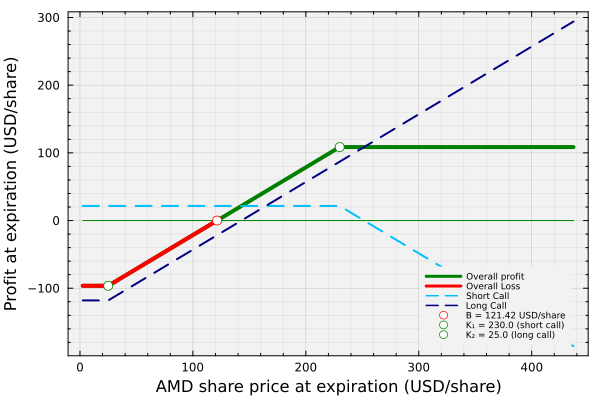

In [15]:
let
    # initialize 
    N = length(profit_array[:,1]); # how many steps do we have?
    BEL = zeros(N);
    K₁ = call_contract_model.K;
    K₂ = my_leap_contract_model.K;
    # Sₚ = my_equity_model.purchase_price

    # SPL_vertical = range(-100,stop=100,length=N) |> collect;
    # SPL_horizontal = Sₒ*ones(N);
    # STRIKE_horizontal = K;

    # setup the coloring -
    profit_idx = findall(>(0), profit_array[:,end])
    loss_array = profit_array[:,:]; loss_array[profit_idx,:] .= NaN
    
    plot(profit_array[:,1],profit_array[:,end], lw=4, c=:green, label="Overall profit", minorgrid = true, xminorticks = 5, yminorticks = 5,
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, legendfontsize=6, legend=:bottomright)
    plot!(loss_array[:,1], loss_array[:,4], lw=4, label="Overall Loss", c=:red)
    plot!(profit_array[:,1], BEL, c=:green, lw=1, label="")
    plot!(profit_array[:,1],profit_array[:,2], lw=2, c=:deepskyblue1, label="Short Call", ls=:dash)
    plot!(profit_array[:,1],profit_array[:,3], lw=2, c=:navy, label="Long Call", ls=:dash)
    
    # scatter!([Sₚ], [0], ms=5, c=:navy, msc=:navy, ls=:dash, label="Sₚ = $(Sₚ) USD/share")
    scatter!([B], [0], ms=5, c=:white, msc=:red, ls=:dash, label="B = $(round(B, digits=4)) USD/share")
    scatter!([K₁],[max_profit], ms=5, label = "K₁ = $(K₁) (short call)", msc=:green, c=:white)
    scatter!([K₂],[max_loss], ms=5, label = "K₂ = $(K₂) (long call)", msc=:green, c=:white)
    # scatter!([max_profit_intersection],[max_profit], ms=5, label = "Opportunity loss = $(max_profit_intersection) USD/share", msc=:navy, c=:white)
    
    xlabel!("AMD share price at expiration (USD/share)", fontsize=18)
    ylabel!("Profit at expiration (USD/share)", fontsize=18)
end

___

## Task 3: Probability of Outcomes
In this task, we estimate the probability of certain outcomes for the synthetic covered call position at expiration. We'll consider three scenarios:

> __Scenarios:__
>
> * __Scenario 1: Maximum profit__. In this scenario, the share price at expiration $S(T)$ exceeds the short strike price $K_{1}$ by at least $\epsilon$ USD/share, where $\epsilon \geq$ `0.01` USD/share. The probability of this scenario occurring is given by $P(S(T) > K_{1} + \epsilon) = 1 - F_{S}\left(K_{1} + \epsilon\right)$.
> * __Scenario 2: Maximum loss__. In this scenario, the share price at expiration $S(T)$ falls below the long strike price $K_{2}$ by at least $\epsilon$ USD/share, where $\epsilon \geq$ `0.01` USD/share. The probability of this scenario occurring is given by $P(S(T) \leq K_{2} - \epsilon) = F_{S}\left(K_{2} - \epsilon\right)$.
> * __Scenario 3: Breakeven__. In this scenario, the share price at expiration $S(T)$ exceeds the breakeven point $B$ by at least $\epsilon$ USD/share, where $\epsilon \geq$ `0.01` USD/share. The probability of this scenario occurring is given by $P(S(T) > B + \epsilon) = 1 - F_{S}\left(B + \epsilon\right)$.

To start, let's build a model of the future underlying share price at expiration $S(T)$ using implied volatility.

### Future share price projection using implied volatility
We could use the __implied volatility__ to estimate the expected share price move over some time $0\rightarrow{T}$. Suppose we construct a [Normal distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.Normal) $\mathcal{N}(\mu_{IV},\sigma_{IV})$ where the mean $\mu_{IV} = S_{0}\exp(\bar{r}\cdot{T\Delta{t}})$, i.e., the risk-neutral future value of the current share price, or just $\mu_{IV}\approx{S}_{0}$ for short duration contracts, and the standard deviation $\sigma_{IV}$ is:
$$
\sigma_{IV} = S_{0}\cdot\left(\frac{\text{IV}}{100}\right)\cdot\sqrt{\text{T}\cdot\Delta{t}}
$$

> __Watch out!__ This model assumes a [Normal distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.Normal), which is problematic because it can emit negative share prices. One way to fix this issue is to use a [Truncated Normal distribution](https://juliastats.org/Distributions.jl/stable/truncate/#Truncated-Distributions) instead.

However, despite the potential issues, this model is __widely__ used to generate quick estimates of future share price ranges using the forward-looking implied volatility. Let's save the Normal IV distribution $\mathcal{N}(\mu_{IV},\sigma_{IV})$ in the `d_IV::Normal` variable:

In [16]:
d_IV = let

    # initialize -
    DTE = metadata["DTE"] |> x-> parse(Float64, x); # days to expiration (units: days)
    ATM_IV = metadata["atm_IV"] |> x-> parse(Float64, x); # atm IV on purchase date, 10-22-2025
    
    # build the Normal model -
    d = Normal(Sₒ*exp(risk_free_rate*DTE*Δt), Sₒ*(ATM_IV)*sqrt(DTE*Δt));
    d; # return
end

Normal{Float64}(μ=227.33162192473233, σ=53.12828738827033)

#### Visualize
`Unhide` the code block below to see how we plotted the probability density function (PDF) for `AMD` share price at contract expiration using the `d_IV` model:

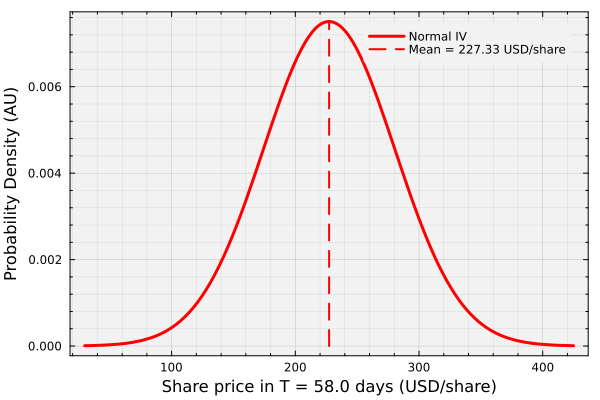

In [17]:
let

    # initialize -
    DTE = metadata["DTE"] |> x-> parse(Float64, x); # days to expiration (units: days)
    LX = ones(100) .* mean(d_IV);
    LY = range(0, stop = maximum(pdf.(d_IV, range(quantile(d_IV,0.01), stop=quantile(d_IV,0.99), length=100))), length = 100) |> collect;

    plot(d_IV, lw=3, label="Normal IV", c=:red, 
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, xminorticks=true, minorgrid = true);
    plot!(LX, LY, lw=2, ls=:dash, c=:red, label="Mean = $(round(mean(d_IV),digits=2)) USD/share")
    
    xlabel!("Share price in T = $(DTE) days (USD/share)", fontsize=18)
    ylabel!("Probability Density (AU)", fontsize=18)
end

### Cumulative distribution
Next, estimate [the cumulative distribution function (CDF)](https://en.wikipedia.org/wiki/Cumulative_distribution_function) for the share price distribution. We can query the cumulative distribution function $F_{S}(\star)$ for the projected distribution `d_IV` using [the `cdf(...)` function exported by the Distributions.jl package](https://github.com/JuliaStats/Distributions.jl?tab=readme-ov-file).

In [Julia we can use the `cdf(...)` function exported from the Distributions.jl package](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.cdf-Tuple{UnivariateDistribution,%20Real}) to compute $F_{S}\left(x\right)$.

Now that we have the cumulative distribution function for the share price distribution, let's compute the probability of observing each of the three scenarios outlined above.

> __Scenario 1: Maximum profit__. In this scenario, the share price at expiration $S(T)$ exceeds the short strike price $K_{1}$ by at least $\epsilon$ USD/share, where $\epsilon \geq$ `0.01` USD/share. The probability of this scenario occurring is given by $P(S(T) > K_{1} + \epsilon) = 1 - F_{S}\left(K_{1} + \epsilon\right)$.

Let's save the probability of this scenario occurring in the `p_max_profit_IV::Float64` variable.

In [18]:
p_max_profit_IV = let

    # initialize 
    ϵ = 0.01; # 1/100 USD
    K₁ = call_contract_model.K;
    p_max_profit_IV = nothing;

    # compute P(S > K₁) for the GBM model
    p_max_profit_IV = 1 - cdf(d_IV,K₁ + ϵ);

    # return data -
    p_max_profit_IV
end;

In [19]:
println("Scenario 1: Probability maximum profit IV = $(p_max_profit_IV)")

Scenario 1: Probability maximum profit IV = 0.4798964756159446


We've seen how to compute the probability of maximum profit using the cumulative distribution function for the share price distribution. Next, let's compute the probability of maximum loss.

> __Scenario 2: Maximum loss__. In this scenario, the share price at expiration $S(T)$ falls below the long strike price $K_{2}$ by at least $\epsilon$ USD/share, where $\epsilon \geq$ `0.01` USD/share. The probability of this scenario occurring is given by $P(S(T) \leq K_{2} - \epsilon) = F_{S}\left(K_{2} - \epsilon\right)$.

We'll save the probability of this scenario occurring in the `p_max_loss_IV::Float64` variable.

In [20]:
p_max_loss_IV = let

    # initialize 
    ϵ = 0.01; # 1/100 USD
    p_max_loss_IV = nothing;
    K₂ = my_leap_contract_model.K;

    # compute the probability P(S(T) ≤ K₂ - ϵ)
    p_max_loss_IV = cdf(d_IV,K₂ - ϵ)
    # return data -
    p_max_loss_IV
end;

In [21]:
println("Scenario 2: Probability max loss IV = $(p_max_loss_IV)")

Scenario 2: Probability max loss IV = 6.989266407302816e-5


Finally, let's compute the probability of at least breaking even on the trade.

> __Scenario 3: Breakeven__. In this scenario, the share price at expiration $S(T)$ exceeds the breakeven point $B$ by at least $\epsilon$ USD/share, where $\epsilon \geq$ `0.01` USD/share. The probability of this scenario occurring is given by $P(S(T) > B + \epsilon) = 1 - F_{S}\left(B + \epsilon\right)$.

We'll save the probability of this scenario occurring in the `p_breakeven_IV::Float64` variable.

In [22]:
p_breakeven_IV = let

    # initialize 
    ϵ = 0.01; # 1/100 USD
    p_breakeven = nothing;

    # compute the probability P(S(T) > B + ϵ)
    p_breakeven = 1 - cdf(d_IV, B + ϵ)

    # return data -
    p_breakeven
end;

In [23]:
println("Scenario 3: Probability of breakeven GBM = $(p_breakeven_IV)")

Scenario 3: Probability of breakeven GBM = 0.9768867335710086


### Discussion
* With a long-term synthetic covered call, do we care if we have a low probability of achieving maximum profit?
* Should we put the short strike _above or below_ the breakeven price of the _long_ share replacement leg? Think about what happens if we need to deliver the shares.

In [24]:
breakeven_leap_contract = let
    K₂ = my_leap_contract_model.K;
    premium_long_call = my_leap_contract_model.premium;
    breakeven_leap_contract = K₂ + premium_long_call;

    # return -
    breakeven_leap_contract;
end

143.0

Is the short strike greater than the breakeven on the long call leg?

In [25]:
short_strike_placed_correctly = let
    K₁ = call_contract_model.K;
    short_strike_placed_correctly = (K₁ ≥ breakeven_leap_contract)
end

true

___

## Summary
This example demonstrates how to construct and analyze a synthetic covered call position using a deep in-the-money call option as a stock replacement combined with a short call at a higher strike.

> __Key Takeaways:__
>
> * __Synthetic covered calls replicate traditional covered calls with lower capital requirements:__ A deep in-the-money call with Delta near 1.0 behaves like owning shares, allowing traders to construct covered call positions at a fraction of the cost of purchasing the underlying stock outright.
> * __Strike selection affects risk and assignment probability:__ Placing the short call strike above the long call's breakeven point ensures that if the short call is assigned, the long call can be exercised profitably to deliver shares without additional capital.
> * __Probability analysis quantifies three key scenarios:__ The likelihood of maximum profit occurs when the share price exceeds the short strike, maximum loss occurs when the share price falls below the long strike, and breakeven probability measures the chance of profitability at expiration.

Understanding synthetic covered call positions enables traders to generate income with reduced capital requirements while maintaining similar risk-reward profiles to traditional covered calls.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.